In [1]:
!pip install transformers==4.41.2
!pip install datasets==2.19.1
!pip install accelerate==0.30.1
!pip install evaluate
!pip install torch
!pip install scikit-learn
!pip install pandas
!pip install matplotlib
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 102.4 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.16.1
    Uninstalling huggingface_hub-1.16.1:
      Successfully uninstalled huggingface_hub-1.16.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 20.9 M

In [4]:
!pip uninstall -y transformers accelerate peft

!pip install transformers==4.41.2
!pip install accelerate==0.30.1
!pip install peft==0.11.1
!pip install datasets==2.19.1

Found existing installation: transformers 4.41.2
Uninstalling transformers-4.41.2:
  Successfully uninstalled transformers-4.41.2
Found existing installation: accelerate 0.30.1
Uninstalling accelerate-0.30.1:
  Successfully uninstalled accelerate-0.30.1
Found existing installation: peft 0.19.1
Uninstalling peft-0.19.1:
  Successfully uninstalled peft-0.19.1
  Using cached transformers-4.41.2-py3-none-any.whl.metadata (43 kB)
Using cached transformers-4.41.2-py3-none-any.whl (9.1 MB)


  Using cached accelerate-0.30.1-py3-none-any.whl.metadata (18 kB)
Using cached accelerate-0.30.1-py3-none-any.whl (302 kB)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 10.2 MB/s eta 0:00:00


In [2]:
from google.colab import files

uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


# import libraries

In [1]:
import pandas as pd
import numpy as np
import re
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from datasets import Dataset

In [2]:
print(torch.cuda.is_available())

True


In [3]:
df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df = df.sample(10000, random_state=42)

In [5]:
df.isnull().sum()

,0
review,0
sentiment,0


In [6]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'<.*?>', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [7]:
df['review'] = df['review'].apply(clean_text)

In [8]:
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

In [9]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['review'],
    df['sentiment'],
    test_size=0.3,
    random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42
)

In [10]:
train_dataset = Dataset.from_dict({
    'text': train_texts.tolist(),
    'label': train_labels.tolist()
})

val_dataset = Dataset.from_dict({
    'text': val_texts.tolist(),
    'label': val_labels.tolist()
})

test_dataset = Dataset.from_dict({
    'text': test_texts.tolist(),
    'label': test_labels.tolist()
})

In [11]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [12]:
def tokenize_function(example):

    return tokenizer(
        example['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

In [13]:
train_dataset = train_dataset.map(tokenize_function, batched=True)

val_dataset = val_dataset.map(tokenize_function, batched=True)

test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

In [14]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [15]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision = precision_score(labels, predictions)

    recall = recall_score(labels, predictions)

    f1 = f1_score(labels, predictions)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [16]:
training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=4,

    per_device_eval_batch_size=4,

    num_train_epochs=1,

    weight_decay=0.01,

    load_best_model_at_end=True
)

In [17]:
trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

In [18]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.468900,0.386744,0.872000,0.864041,0.888889,0.876289


TrainOutput(global_step=1750, training_loss=0.48616990879603794, metrics={'train_runtime': 247.133, 'train_samples_per_second': 28.325, 'train_steps_per_second': 7.081, 'total_flos': 231817947648000.0, 'train_loss': 0.48616990879603794, 'epoch': 1.0})

In [19]:
results = trainer.evaluate(test_dataset)

print(results)

{'eval_loss': 0.4619322419166565, 'eval_accuracy': 0.8506666666666667, 'eval_precision': 0.8373879641485276, 'eval_recall': 0.8708388814913449, 'eval_f1': 0.8537859007832899, 'eval_runtime': 14.6046, 'eval_samples_per_second': 102.707, 'eval_steps_per_second': 25.677, 'epoch': 1.0}


In [20]:
predictions = trainer.predict(test_dataset)

preds = np.argmax(predictions.predictions, axis=-1)

In [21]:
print(classification_report(test_labels, preds))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85       749
           1       0.84      0.87      0.85       751

    accuracy                           0.85      1500
   macro avg       0.85      0.85      0.85      1500
weighted avg       0.85      0.85      0.85      1500



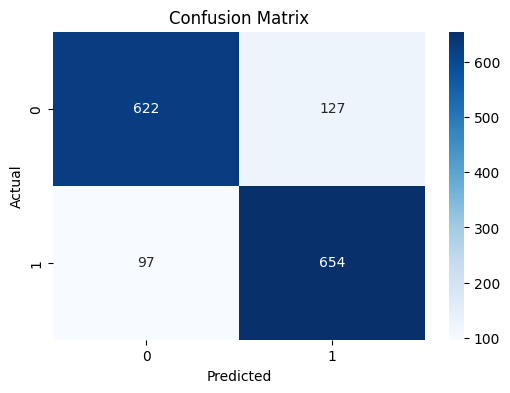

In [22]:
cm = confusion_matrix(test_labels, preds)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()